# Olist E-Commerce Data Analysis

Data cleaning, exploratory analysis, and SQL-based business insights on the Olist Brazilian e-commerce dataset.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

## 1. Load Raw Data

In [2]:
folder_path = r"D:\archive (1)\*.csv"
file_paths = glob.glob(folder_path)

tables = {}
for file in file_paths:
    name = os.path.basename(file).split('.')[0]
    tables[name] = pd.read_csv(file)
    print(f"Loaded {name}: {tables[name].shape}")

Loaded customer_segments: (4338, 5)
Loaded olist_customers_dataset: (99441, 5)
Loaded olist_geolocation_dataset: (1000163, 5)
Loaded olist_orders_dataset: (99441, 8)
Loaded olist_order_items_dataset: (112650, 7)
Loaded olist_order_payments_dataset: (103886, 5)
Loaded olist_order_reviews_dataset: (99224, 7)
Loaded olist_products_dataset: (32951, 9)
Loaded olist_sellers_dataset: (3095, 4)
Loaded product_category_name_translation: (71, 2)


## 2. Initial Data Overview

In [3]:
for name, df in tables.items():
    print(f"\n{name}  |  {df.shape[0]:,} rows x {df.shape[1]} cols")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"Missing values:\n{missing}")
    print(f"Duplicate rows: {df.duplicated().sum()}")


customer_segments  |  4,338 rows x 5 cols
Duplicate rows: 0

olist_customers_dataset  |  99,441 rows x 5 cols
Duplicate rows: 0

olist_geolocation_dataset  |  1,000,163 rows x 5 cols
Duplicate rows: 261831

olist_orders_dataset  |  99,441 rows x 8 cols
Missing values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicate rows: 0

olist_order_items_dataset  |  112,650 rows x 7 cols
Duplicate rows: 0

olist_order_payments_dataset  |  103,886 rows x 5 cols
Duplicate rows: 0

olist_order_reviews_dataset  |  99,224 rows x 7 cols
Missing values:
review_comment_title      87656
review_comment_message    58247
dtype: int64
Duplicate rows: 0

olist_products_dataset  |  32,951 rows x 9 cols
Missing values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
produc

## 3. Data Cleaning

### 3.1 Remove Duplicate Rows

In [4]:
for name, df in tables.items():
    before = len(df)
    tables[name] = df.drop_duplicates().reset_index(drop=True)
    removed = before - len(tables[name])
    if removed:
        print(f"{name}: removed {removed} duplicate rows")

olist_geolocation_dataset: removed 261831 duplicate rows


### 3.2 Deduplicate Geolocation by Zip Code

The geolocation table has many lat/lng entries per zip code prefix. Collapse to one representative row per zip.

In [5]:
geo = tables["olist_geolocation_dataset"]
tables["olist_geolocation_dataset"] = (
    geo.groupby("geolocation_zip_code_prefix", as_index=False)
       .agg({
           "geolocation_lat": "mean",
           "geolocation_lng": "mean",
           "geolocation_city": "first",
           "geolocation_state": "first"
       })
)
print(f"Geolocation reduced to {len(tables['olist_geolocation_dataset']):,} unique zip codes")

Geolocation reduced to 19,015 unique zip codes


### 3.3 Missing Values — Orders

Missing approval/delivery dates correspond to orders that never reached that stage (e.g. canceled). Convert to datetime and keep these as NaT rather than imputing.

In [6]:
orders = tables["olist_orders_dataset"]
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")
tables["olist_orders_dataset"] = orders

### 3.4 Missing Values — Reviews

A missing title/message just means the customer left no comment.

In [7]:
reviews = tables["olist_order_reviews_dataset"]
reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")
tables["olist_order_reviews_dataset"] = reviews

### 3.5 Missing Values — Products

Missing category is filled as 'unknown'. The handful of missing physical dimensions are filled with the column median.

In [8]:
products = tables["olist_products_dataset"]
products["product_category_name"] = products["product_category_name"].fillna("unknown")

numeric_cols = ["product_name_lenght", "product_description_lenght", "product_photos_qty",
                "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
for col in numeric_cols:
    products[col] = products[col].fillna(products[col].median())

tables["olist_products_dataset"] = products

### 3.6 Post-Cleaning Verification

In [9]:
for name, df in tables.items():
    print(f"{name}: missing={df.isnull().sum().sum()}, duplicates={df.duplicated().sum()}")

customer_segments: missing=0, duplicates=0
olist_customers_dataset: missing=0, duplicates=0
olist_geolocation_dataset: missing=0, duplicates=0
olist_orders_dataset: missing=4908, duplicates=0
olist_order_items_dataset: missing=0, duplicates=0
olist_order_payments_dataset: missing=0, duplicates=0
olist_order_reviews_dataset: missing=0, duplicates=0
olist_products_dataset: missing=0, duplicates=0
olist_sellers_dataset: missing=0, duplicates=0
product_category_name_translation: missing=0, duplicates=0


## 4. Load Cleaned Data into SQLite

In [10]:
engine = create_engine("sqlite:///olist.db")
for name, df in tables.items():
    df.to_sql(name, engine, if_exists="replace", index=False)

def run_query(sql, title=""):
    with engine.connect() as conn:
        df = pd.read_sql(text(sql), conn)
    print(f"\n{title}")
    print(df.to_string(index=False))
    return df

os.makedirs("power_bi_exports", exist_ok=True)

def run_and_export(sql, title, filename):
    df = run_query(sql, title)
    df.to_csv(f"power_bi_exports/{filename}.csv", index=False)
    return df

## 5. Exploratory Data Analysis — Visual Snapshot

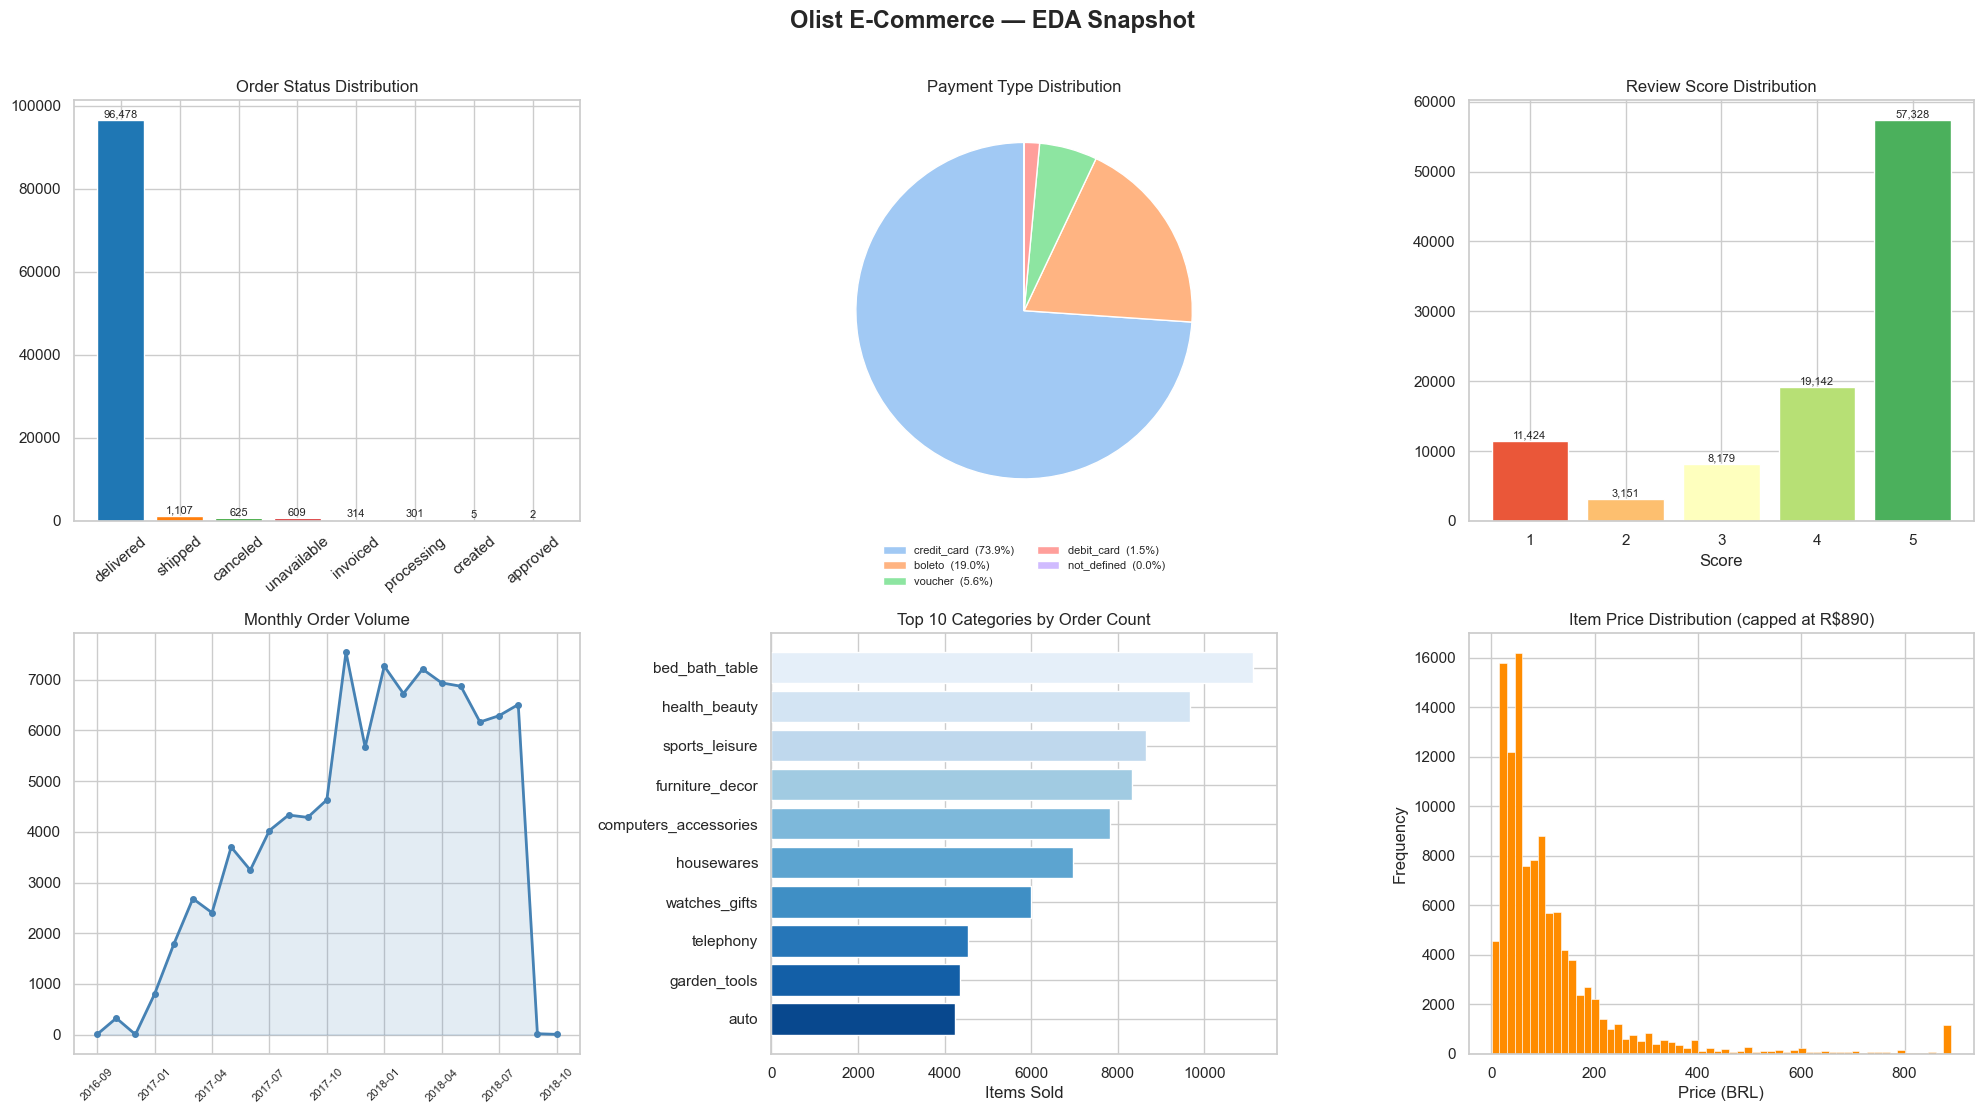

In [11]:
orders   = tables["olist_orders_dataset"]
items    = tables["olist_order_items_dataset"]
payments = tables["olist_order_payments_dataset"]
reviews  = tables["olist_order_reviews_dataset"]
products = tables["olist_products_dataset"]
trans    = tables["product_category_name_translation"]

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Olist E-Commerce — EDA Snapshot", fontsize=17, fontweight="bold", y=1.01)

status_counts = orders["order_status"].value_counts()
axes[0, 0].bar(status_counts.index, status_counts.values,
               color=sns.color_palette("tab10", len(status_counts)))
axes[0, 0].set_title("Order Status Distribution")
axes[0, 0].tick_params(axis="x", rotation=40)
for bar, val in zip(axes[0, 0].patches, status_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                     f"{val:,}", ha="center", va="bottom", fontsize=8)

pay_counts = payments["payment_type"].value_counts()
colors = sns.color_palette("pastel", len(pay_counts))
total = pay_counts.sum()
wedges, _ = axes[0, 1].pie(pay_counts.values, labels=None, autopct=None,
                            startangle=90, colors=colors)
legend_labels = [f"{lbl}  ({v/total*100:.1f}%)" for lbl, v in zip(pay_counts.index, pay_counts.values)]
axes[0, 1].legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.18),
                   ncol=2, fontsize=8, frameon=False)
axes[0, 1].set_title("Payment Type Distribution")

review_counts = reviews["review_score"].value_counts().sort_index()
bars = axes[0, 2].bar(review_counts.index.astype(str), review_counts.values,
                       color=sns.color_palette("RdYlGn", 5))
axes[0, 2].set_title("Review Score Distribution")
axes[0, 2].set_xlabel("Score")
for bar, val in zip(bars, review_counts.values):
    axes[0, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                     f"{val:,}", ha="center", va="bottom", fontsize=8)

monthly_orders = (orders.groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
                        .size().reset_index(name="count"))
monthly_orders["month_str"] = monthly_orders["order_purchase_timestamp"].astype(str)
axes[1, 0].plot(monthly_orders["month_str"], monthly_orders["count"],
                 marker="o", linewidth=2, color="steelblue", markersize=4)
axes[1, 0].fill_between(monthly_orders["month_str"], monthly_orders["count"],
                         alpha=0.15, color="steelblue")
axes[1, 0].set_title("Monthly Order Volume")
axes[1, 0].set_xticks(range(0, len(monthly_orders), 3))
axes[1, 0].set_xticklabels(list(monthly_orders["month_str"])[::3], rotation=45, fontsize=8)

merged_cats = (items.merge(products[["product_id", "product_category_name"]], on="product_id")
                     .merge(trans, on="product_category_name", how="left"))
top_cats = merged_cats["product_category_name_english"].value_counts().head(10)
axes[1, 1].barh(top_cats.index[::-1], top_cats.values[::-1],
                 color=sns.color_palette("Blues_r", 10))
axes[1, 1].set_title("Top 10 Categories by Order Count")
axes[1, 1].set_xlabel("Items Sold")

price_cap = items["price"].quantile(0.99)
axes[1, 2].hist(items["price"].clip(upper=price_cap), bins=60,
                 color="darkorange", edgecolor="white", linewidth=0.4)
axes[1, 2].set_title(f"Item Price Distribution (capped at R${price_cap:.0f})")
axes[1, 2].set_xlabel("Price (BRL)")
axes[1, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("olist_eda_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. SQL Analysis

15 business queries, each run against the cleaned SQLite database and exported to CSV.

### Q1 · Monthly Revenue Trend

In [12]:
q1 = run_and_export("""
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp)   AS month,
        COUNT(DISTINCT o.order_id)                      AS total_orders,
        ROUND(SUM(oi.price), 2)                         AS product_revenue,
        ROUND(SUM(oi.freight_value), 2)                 AS freight_revenue,
        ROUND(SUM(oi.price + oi.freight_value), 2)      AS gross_revenue
    FROM olist_orders_dataset      o
    JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
    WHERE o.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY month
    ORDER BY month;
""", "Q1 · Monthly Revenue Trend", "q1_monthly_revenue")


Q1 · Monthly Revenue Trend
  month  total_orders  product_revenue  freight_revenue  gross_revenue
2016-09             2           207.86            71.83         279.69
2016-10           290         44507.30          6847.22       51354.52
2016-12             1            10.90             8.72          19.62
2017-01           787        120098.27         16845.19      136943.46
2017-02          1718        244959.35         38602.34      283561.69
2017-03          2617        368341.32         57276.64      425617.96
2017-04          2377        353842.98         52005.63      405848.61
2017-05          3640        503159.19         79551.64      582710.83
2017-06          3205        429916.61         69735.63      499652.24
2017-07          3946        492287.30         86466.43      578753.73
2017-08          4272        568245.79         93657.73      661903.52
2017-09          4227        621415.91         95686.81      717102.72
2017-10          4547        660179.62        104

### Q2 · Top 10 Product Categories by Revenue

In [13]:
q2 = run_and_export("""
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name)          AS category,
        COUNT(oi.order_item_id)                    AS items_sold,
        ROUND(SUM(oi.price), 2)                    AS revenue,
        ROUND(AVG(oi.price), 2)                    AS avg_price,
        ROUND(AVG(oi.freight_value), 2)            AS avg_freight
    FROM olist_order_items_dataset                 oi
    JOIN olist_products_dataset                    p  ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation    t  ON p.product_category_name = t.product_category_name
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 10;
""", "Q2 · Top 10 Product Categories by Revenue", "q2_top_categories")


Q2 · Top 10 Product Categories by Revenue
             category  items_sold    revenue  avg_price  avg_freight
        health_beauty        9670 1258681.34     130.16        18.88
        watches_gifts        5991 1205005.68     201.14        16.78
       bed_bath_table       11115 1036988.68      93.30        18.42
       sports_leisure        8641  988048.97     114.34        19.51
computers_accessories        7827  911954.32     116.51        18.82
      furniture_decor        8334  729762.49      87.56        20.73
           cool_stuff        3796  635290.85     167.36        22.14
           housewares        6964  632248.66      90.79        20.99
                 auto        4235  592720.11     139.96        21.88
         garden_tools        4347  485256.46     111.63        22.77


### Q3 · Customer Lifetime Value (Top 20)

In [14]:
q3 = run_and_export("""
    SELECT
        c.customer_unique_id,
        c.customer_state,
        COUNT(DISTINCT o.order_id)                   AS total_orders,
        ROUND(SUM(oi.price + oi.freight_value), 2)  AS lifetime_value,
        ROUND(AVG(oi.price + oi.freight_value), 2)  AS avg_order_value,
        MIN(o.order_purchase_timestamp)              AS first_order,
        MAX(o.order_purchase_timestamp)              AS last_order
    FROM olist_customers_dataset       c
    JOIN olist_orders_dataset          o  ON c.customer_id = o.customer_id
    JOIN olist_order_items_dataset     oi ON o.order_id    = oi.order_id
    GROUP BY c.customer_unique_id, c.customer_state
    ORDER BY lifetime_value DESC
    LIMIT 20;
""", "Q3 · Customer Lifetime Value (Top 20)", "q3_customer_ltv")


Q3 · Customer Lifetime Value (Top 20)
              customer_unique_id customer_state  total_orders  lifetime_value  avg_order_value                first_order                 last_order
0a0a92112bd4c708ca5fde585afaa872             RJ             1        13664.08          1708.01 2017-09-29 15:24:52.000000 2017-09-29 15:24:52.000000
da122df9eeddfedc1dc1f5349a1a690c             RJ             2         7571.63          3785.82 2017-04-01 15:58:40.000000 2017-04-01 15:58:41.000000
763c8b1c9c68a0229c42c9fc6f662b93             ES             1         7274.88          1818.72 2018-07-15 14:49:44.000000 2018-07-15 14:49:44.000000
dc4802a71eae9be1dd28f5d788ceb526             MS             1         6929.31          6929.31 2017-02-12 20:37:36.000000 2017-02-12 20:37:36.000000
459bef486812aa25204be022145caa62             ES             1         6922.21          6922.21 2018-07-25 18:10:17.000000 2018-07-25 18:10:17.000000
ff4159b92c40ebe40454e3e6a7c35ed6             SP             1      

### Q4 · Seller Performance Ranking (DENSE_RANK)

In [15]:
q4 = run_and_export("""
    SELECT
        s.seller_id,
        s.seller_state,
        COUNT(DISTINCT oi.order_id)                         AS orders_fulfilled,
        ROUND(SUM(oi.price), 2)                            AS total_revenue,
        ROUND(AVG(r.review_score), 2)                      AS avg_review_score,
        DENSE_RANK() OVER (ORDER BY SUM(oi.price) DESC)    AS revenue_rank
    FROM olist_sellers_dataset             s
    JOIN olist_order_items_dataset         oi ON s.seller_id  = oi.seller_id
    JOIN olist_orders_dataset              o  ON oi.order_id  = o.order_id
    LEFT JOIN olist_order_reviews_dataset  r  ON o.order_id   = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY s.seller_id, s.seller_state
    ORDER BY revenue_rank
    LIMIT 20;
""", "Q4 · Seller Performance Ranking (DENSE_RANK)", "q4_seller_ranking")


Q4 · Seller Performance Ranking (DENSE_RANK)
                       seller_id seller_state  orders_fulfilled  total_revenue  avg_review_score  revenue_rank
4869f7a5dfa277a7dca6462dcf3b52b2           SP              1124      226987.93              4.14             1
53243585a1d6dc2643021fd1853d8905           BA               348      217940.44              4.13             2
4a3ca9315b744ce9f8e9374361493884           SP              1772      199408.32              3.83             3
fa1c13f2614d7b5c4749cbc52fecda94           SP               578      190917.14              4.37             4
7c67e1448b00f6e969d365cea6b010ab           SP               973      188063.83              3.35             5
7e93a43ef30c4f03f38b393420bc753a           SP               319      165981.49              4.36             6
da8622b14eb17ae2831f4ac5b9dab84a           SP              1311      162303.67              4.08             7
7a67c85e85bb2ce8582c35f2203ad736           SP              1145   

### Q5 · Actual vs Estimated Delivery Days by State

In [16]:
q5 = run_and_export("""
    SELECT
        c.customer_state,
        COUNT(o.order_id)                                                                  AS delivered_orders,
        ROUND(AVG(julianday(o.order_delivered_customer_date)
                - julianday(o.order_purchase_timestamp)), 1)                               AS avg_actual_days,
        ROUND(AVG(julianday(o.order_estimated_delivery_date)
                - julianday(o.order_purchase_timestamp)), 1)                               AS avg_estimated_days,
        ROUND(AVG(julianday(o.order_estimated_delivery_date)
                - julianday(o.order_delivered_customer_date)), 1)                          AS avg_days_ahead_of_estimate
    FROM olist_orders_dataset     o
    JOIN olist_customers_dataset  c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    ORDER BY avg_actual_days DESC;
""", "Q5 · Actual vs Estimated Delivery Days by State", "q5_delivery_time")


Q5 · Actual vs Estimated Delivery Days by State
customer_state  delivered_orders  avg_actual_days  avg_estimated_days  avg_days_ahead_of_estimate
            RR                41             29.4                46.0                        16.6
            AP                67             27.2                46.2                        19.1
            AM               145             26.4                45.3                        18.9
            AL               397             24.5                32.6                         8.0
            PA               946             23.8                37.2                        13.4
            MA               717             21.6                30.5                         8.9
            SE               335             21.5                30.8                         9.3
            CE              1279             21.3                31.4                        10.1
            AC                80             21.0                41.1

### Q6 · Payment Method Split & Instalment Behaviour

In [17]:
q6 = run_and_export("""
    SELECT
        payment_type,
        COUNT(*)                                                   AS txn_count,
        ROUND(SUM(payment_value), 2)                              AS total_value,
        ROUND(AVG(payment_value), 2)                              AS avg_ticket,
        ROUND(AVG(payment_installments), 1)                       AS avg_installments,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)        AS pct_of_txns,
        ROUND(100.0 * SUM(payment_value)
              / SUM(SUM(payment_value)) OVER (), 2)               AS pct_of_revenue
    FROM olist_order_payments_dataset
    GROUP BY payment_type
    ORDER BY total_value DESC;
""", "Q6 · Payment Method Split & Instalment Behaviour", "q6_payment_split")


Q6 · Payment Method Split & Instalment Behaviour
payment_type  txn_count  total_value  avg_ticket  avg_installments  pct_of_txns  pct_of_revenue
 credit_card      76795  12542084.19      163.32               3.5        73.92           78.34
      boleto      19784   2869361.27      145.03               1.0        19.04           17.92
     voucher       5775    379436.87       65.70               1.0         5.56            2.37
  debit_card       1529    217989.79      142.57               1.0         1.47            1.36
 not_defined          3         0.00        0.00               1.0         0.00            0.00


### Q7 · Review Score Breakdown by Category

In [18]:
q7 = run_and_export("""
    WITH category_reviews AS (
        SELECT
            COALESCE(t.product_category_name_english,
                     p.product_category_name)    AS category,
            r.review_score
        FROM olist_order_items_dataset             oi
        JOIN olist_products_dataset                p  ON oi.product_id  = p.product_id
        LEFT JOIN product_category_name_translation t  ON p.product_category_name = t.product_category_name
        JOIN olist_orders_dataset                  o  ON oi.order_id    = o.order_id
        JOIN olist_order_reviews_dataset           r  ON o.order_id     = r.order_id
    )
    SELECT
        category,
        COUNT(*)                                                             AS review_count,
        ROUND(AVG(review_score), 2)                                         AS avg_score,
        ROUND(100.0 * SUM(CASE WHEN review_score = 5 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                                 AS pct_5star,
        ROUND(100.0 * SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                                 AS pct_positive,
        ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                                 AS pct_negative
    FROM category_reviews
    GROUP BY category
    HAVING review_count > 100
    ORDER BY avg_score DESC
    LIMIT 20;
""", "Q7 · Review Score Breakdown by Category", "q7_review_by_category")


Q7 · Review Score Breakdown by Category
                category  review_count  avg_score  pct_5star  pct_positive  pct_negative
  books_general_interest           549       4.45       72.5          87.8           8.6
         books_technical           266       4.37       70.7          85.3          10.9
     luggage_accessories          1088       4.32       64.8          83.7           9.7
              food_drink           279       4.32       63.8          81.7           7.9
           fashion_shoes           261       4.23       63.6          80.8          12.3
                    food           495       4.22       63.2          81.8          12.9
              stationery          2507       4.19       61.6          80.7          13.1
                pet_shop          1939       4.19       61.7          79.7          12.9
               computers           200       4.18       61.0          81.5          13.0
         home_appliances           806       4.17       59.6         

### Q8 · Late Delivery Rate by Seller State

In [19]:
q8 = run_and_export("""
    SELECT
        s.seller_state,
        COUNT(DISTINCT o.order_id)                                                     AS total_orders,
        SUM(CASE
            WHEN julianday(o.order_delivered_customer_date)
               > julianday(o.order_estimated_delivery_date) THEN 1 ELSE 0
            END)                                                                        AS late_deliveries,
        ROUND(100.0 * SUM(CASE
            WHEN julianday(o.order_delivered_customer_date)
               > julianday(o.order_estimated_delivery_date) THEN 1 ELSE 0
            END) / COUNT(DISTINCT o.order_id), 2)                                      AS late_pct,
        ROUND(AVG(CASE
            WHEN julianday(o.order_delivered_customer_date)
               > julianday(o.order_estimated_delivery_date)
            THEN julianday(o.order_delivered_customer_date)
               - julianday(o.order_estimated_delivery_date)
            END), 1)                                                                    AS avg_days_overdue
    FROM olist_orders_dataset           o
    JOIN olist_order_items_dataset      oi ON o.order_id   = oi.order_id
    JOIN olist_sellers_dataset          s  ON oi.seller_id = s.seller_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY s.seller_state
    ORDER BY late_pct DESC;
""", "Q8 · Late Delivery Rate by Seller State", "q8_late_delivery")


Q8 · Late Delivery Rate by Seller State
seller_state  total_orders  late_deliveries  late_pct  avg_days_overdue
          AM             3                2     66.67              19.2
          MA           389               95     24.42               7.0
          PA             8                1     12.50               1.0
          RN            51                6     11.76               7.2
          SP         68635             6697      9.76               9.0
          CE            87                8      9.20              20.6
          RJ          4227              380      8.99              10.1
          MS            49                4      8.16               5.8
          ES           310               24      7.74              10.6
          DF           808               59      7.30               8.7
          PR          7512              548      7.29              10.9
          SC          3603              235      6.52              10.8
          BA           

### Q9 · Month-over-Month Revenue Growth (LAG)

In [20]:
q9 = run_and_export("""
    WITH monthly AS (
        SELECT
            strftime('%Y-%m', o.order_purchase_timestamp)  AS month,
            ROUND(SUM(oi.price + oi.freight_value), 2)     AS revenue
        FROM olist_orders_dataset      o
        JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
        GROUP BY month
    )
    SELECT
        month,
        revenue,
        LAG(revenue)  OVER (ORDER BY month)                                           AS prev_month_revenue,
        ROUND(revenue - LAG(revenue) OVER (ORDER BY month), 2)                        AS revenue_delta,
        ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY month))
              / NULLIF(LAG(revenue) OVER (ORDER BY month), 0), 2)                     AS mom_growth_pct
    FROM monthly
    ORDER BY month;
""", "Q9 · Month-over-Month Revenue Growth (LAG)", "q9_mom_growth")


Q9 · Month-over-Month Revenue Growth (LAG)
  month    revenue  prev_month_revenue  revenue_delta  mom_growth_pct
2016-09     279.69                 NaN            NaN             NaN
2016-10   51354.52              279.69       51074.83        18261.23
2016-12      19.62            51354.52      -51334.90          -99.96
2017-01  136943.46               19.62      136923.84       697878.90
2017-02  283561.69           136943.46      146618.23          107.06
2017-03  425617.96           283561.69      142056.27           50.10
2017-04  405848.61           425617.96      -19769.35           -4.64
2017-05  582710.83           405848.61      176862.22           43.58
2017-06  499652.24           582710.83      -83058.59          -14.25
2017-07  578753.73           499652.24       79101.49           15.83
2017-08  661903.52           578753.73       83149.79           14.37
2017-09  717102.72           661903.52       55199.20            8.34
2017-10  764756.03           717102.72       4

### Q10 · RFM Segmentation (NTILE Quintiles)

In [21]:
q10 = run_and_export("""
    WITH rfm_raw AS (
        SELECT
            c.customer_unique_id,
            MAX(o.order_purchase_timestamp)               AS last_purchase,
            COUNT(DISTINCT o.order_id)                    AS frequency,
            ROUND(SUM(oi.price + oi.freight_value), 2)   AS monetary
        FROM olist_customers_dataset       c
        JOIN olist_orders_dataset          o  ON c.customer_id = o.customer_id
        JOIN olist_order_items_dataset     oi ON o.order_id    = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY last_purchase DESC)  AS r_score,
            NTILE(5) OVER (ORDER BY frequency ASC)       AS f_score,
            NTILE(5) OVER (ORDER BY monetary ASC)        AS m_score
        FROM rfm_raw
    )
    SELECT
        r_score,
        f_score,
        m_score,
        r_score + f_score + m_score                      AS rfm_total,
        COUNT(*)                                          AS customer_count,
        ROUND(AVG(monetary), 2)                          AS avg_monetary,
        ROUND(AVG(frequency), 2)                         AS avg_frequency
    FROM rfm_scored
    GROUP BY r_score, f_score, m_score
    ORDER BY rfm_total DESC
    LIMIT 25;
""", "Q10 · RFM Segmentation (NTILE Quintiles)", "q10_rfm")


Q10 · RFM Segmentation (NTILE Quintiles)
 r_score  f_score  m_score  rfm_total  customer_count  avg_monetary  avg_frequency
       5        5        5         15            3466        458.45           1.07
       4        5        5         14            3540        468.46           1.09
       5        4        5         14             254        213.33           1.00
       5        5        4         14             109        168.81           2.05
       3        5        5         13            3279        429.91           1.12
       4        4        5         13             237        213.24           1.00
       4        5        4         13             140        169.60           2.06
       5        4        4         13            3217        164.50           1.00
       5        5        3         13              66        110.55           2.14
       2        5        5         12            3558        469.74           1.11
       3        4        5         12        

### Q11 · Cumulative Revenue Running Total

In [22]:
q11 = run_and_export("""
    WITH monthly AS (
        SELECT
            strftime('%Y-%m', o.order_purchase_timestamp) AS month,
            ROUND(SUM(oi.price + oi.freight_value), 2)    AS revenue
        FROM olist_orders_dataset      o
        JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
        WHERE o.order_status NOT IN ('canceled', 'unavailable')
        GROUP BY month
    )
    SELECT
        month,
        revenue,
        ROUND(SUM(revenue) OVER (ORDER BY month
              ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 2)   AS cumulative_revenue,
        ROUND(100.0 * revenue
              / SUM(revenue) OVER (), 2)                               AS monthly_share_pct
    FROM monthly
    ORDER BY month;
""", "Q11 · Cumulative Revenue Running Total", "q11_cumulative_revenue")


Q11 · Cumulative Revenue Running Total
  month    revenue  cumulative_revenue  monthly_share_pct
2016-09     279.69              279.69               0.00
2016-10   51354.52            51634.21               0.33
2016-12      19.62            51653.83               0.00
2017-01  136943.46           188597.29               0.87
2017-02  283561.69           472158.98               1.80
2017-03  425617.96           897776.94               2.70
2017-04  405848.61          1303625.55               2.58
2017-05  582710.83          1886336.38               3.70
2017-06  499652.24          2385988.62               3.18
2017-07  578753.73          2964742.35               3.68
2017-08  661903.52          3626645.87               4.21
2017-09  717102.72          4343748.59               4.56
2017-10  764756.03          5108504.62               4.86
2017-11 1172191.68          6280696.30               7.45
2017-12  861526.77          7142223.07               5.48
2018-01 1101920.01          8244

### Q12 · State Revenue Market Share + Pareto Cumulative %

In [23]:
q12 = run_and_export("""
    SELECT
        c.customer_state,
        COUNT(DISTINCT o.order_id)                                               AS orders,
        ROUND(SUM(oi.price + oi.freight_value), 2)                              AS revenue,
        ROUND(100.0 * SUM(oi.price + oi.freight_value)
              / SUM(SUM(oi.price + oi.freight_value)) OVER (), 2)               AS revenue_share_pct,
        ROUND(SUM(SUM(oi.price + oi.freight_value)) OVER (
                ORDER BY SUM(oi.price + oi.freight_value) DESC
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
              / SUM(SUM(oi.price + oi.freight_value)) OVER () * 100, 1)         AS cumulative_share_pct
    FROM olist_orders_dataset           o
    JOIN olist_customers_dataset        c  ON o.customer_id = c.customer_id
    JOIN olist_order_items_dataset      oi ON o.order_id    = oi.order_id
    GROUP BY c.customer_state
    ORDER BY revenue DESC;
""", "Q12 · State Revenue Market Share + Pareto Cumulative %", "q12_state_market_share")


Q12 · State Revenue Market Share + Pareto Cumulative %
customer_state  orders    revenue  revenue_share_pct  cumulative_share_pct
            SP   41375 5921678.12              37.38                  37.4
            RJ   12762 2129681.98              13.44                  50.8
            MG   11544 1856161.49              11.72                  62.5
            RS    5432  885826.76               5.59                  68.1
            PR    4998  800935.44               5.06                  73.2
            BA    3358  611506.67               3.86                  77.0
            SC    3612  610213.60               3.85                  80.9
            DF    2125  353229.44               2.23                  83.1
            GO    2007  347706.93               2.19                  85.3
            ES    2025  324801.91               2.05                  87.4
            PE    1648  322237.69               2.03                  89.4
            CE    1327  275606.30           

### Q13 · Top Product Pairs Bought Together (Co-Purchase Self-Join)

In [24]:
q13 = run_and_export("""
    SELECT
        a.product_id        AS product_a,
        b.product_id        AS product_b,
        COUNT(*)            AS co_purchase_count
    FROM olist_order_items_dataset a
    JOIN olist_order_items_dataset b
        ON  a.order_id   = b.order_id
        AND a.product_id < b.product_id
    GROUP BY a.product_id, b.product_id
    ORDER BY co_purchase_count DESC
    LIMIT 15;
""", "Q13 · Top Product Pairs Bought Together (Co-Purchase Self-Join)", "q13_co_purchase")


Q13 · Top Product Pairs Bought Together (Co-Purchase Self-Join)
                       product_a                        product_b  co_purchase_count
05b515fdc76e888aada3c6d66c201dff 270516a3f41dc035aa87d220228f844c                100
36f60d45225e60c7da4558b070ce4b60 e53e557d5a159f5aa2c5e995dfdf244b                 48
62995b7e571f5760017991632bbfd311 ac1ad58efc1ebf66bfadc09f29bdedc0                 36
710b7c26b7a742f497bba45fab91a25f a9d9db064d4afd4458eb3e139fe29167                 36
2ef36e1cae01b86d0ff0a2f50ff2bd53 53759a2ecddad2bb87a079a1f1519f73                 30
308e4e21ae228a10f6370a243ae59995 90b58782fdd04cb829667fcc41fb65f5                 30
35afc973633aaeb6b877ff57b2793310 99a4788cb24856965c36a24e339b6058                 30
18486698933fbb64af6c0a255f7dd64c dbb67791e405873b259e4656bf971246                 26
58efb9b638561ce132216a9a612513e2 872db866d615db59612ac933f43d6b22                 25
0db4869ac8a908414823d44d742f5ba3 47920da896bbd89e851429c78a7a7a8b                 24


### Q14 · Order-to-Delivery Funnel Timing by Stage (Hours)

In [25]:
q14 = run_and_export("""
    SELECT
        c.customer_state,
        COUNT(o.order_id)                                                                       AS orders,
        ROUND(AVG((julianday(o.order_approved_at)
                 - julianday(o.order_purchase_timestamp)) * 24), 1)                             AS hrs_to_approval,
        ROUND(AVG((julianday(o.order_delivered_carrier_date)
                 - julianday(o.order_approved_at)) * 24), 1)                                    AS hrs_approval_to_carrier,
        ROUND(AVG((julianday(o.order_delivered_customer_date)
                 - julianday(o.order_delivered_carrier_date)) * 24), 1)                         AS hrs_carrier_to_customer,
        ROUND(AVG((julianday(o.order_delivered_customer_date)
                 - julianday(o.order_purchase_timestamp)) * 24), 1)                             AS hrs_total_end_to_end
    FROM olist_orders_dataset     o
    JOIN olist_customers_dataset  c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_approved_at              IS NOT NULL
      AND o.order_delivered_carrier_date   IS NOT NULL
      AND o.order_delivered_customer_date  IS NOT NULL
    GROUP BY c.customer_state
    ORDER BY hrs_total_end_to_end DESC;
""", "Q14 · Order-to-Delivery Funnel Timing by Stage (Hours)", "q14_delivery_funnel")


Q14 · Order-to-Delivery Funnel Timing by Stage (Hours)
customer_state  orders  hrs_to_approval  hrs_approval_to_carrier  hrs_carrier_to_customer  hrs_total_end_to_end
            RR      41              9.5                     80.3                    615.5                 705.3
            AP      67             15.3                     69.2                    567.9                 652.4
            AM     145              9.8                     60.0                    564.5                 634.2
            AL     397             11.7                     71.3                    506.0                 589.1
            PA     946             12.2                     71.4                    486.9                 570.6
            MA     716             13.9                     72.6                    431.6                 518.0
            SE     335             10.1                     75.7                    430.7                 516.5
            CE    1278             11.3         

### Q15 · Freight Cost as % of Product Revenue by Category (RANK)

In [26]:
q15 = run_and_export("""
    WITH cat_freight AS (
        SELECT
            COALESCE(t.product_category_name_english,
                     p.product_category_name)      AS category,
            COUNT(oi.order_item_id)                AS items_sold,
            ROUND(SUM(oi.price), 2)                AS total_revenue,
            ROUND(SUM(oi.freight_value), 2)        AS total_freight
        FROM olist_order_items_dataset                 oi
        JOIN olist_products_dataset                    p  ON oi.product_id = p.product_id
        LEFT JOIN product_category_name_translation    t  ON p.product_category_name = t.product_category_name
        GROUP BY category
        HAVING items_sold > 30
    )
    SELECT
        category,
        items_sold,
        total_revenue,
        total_freight,
        ROUND(100.0 * total_freight / NULLIF(total_revenue, 0), 2)          AS freight_pct,
        RANK() OVER (ORDER BY total_freight / NULLIF(total_revenue, 0) DESC) AS freight_burden_rank
    FROM cat_freight
    ORDER BY freight_pct DESC
    LIMIT 15;
""", "Q15 · Freight Cost as % of Product Revenue by Category (RANK)", "q15_freight_burden")


Q15 · Freight Cost as % of Product Revenue by Category (RANK)
                               category  items_sold  total_revenue  total_freight  freight_pct  freight_burden_rank
                                flowers          33        1110.04         488.87        44.04                    1
      furniture_mattress_and_upholstery          38        4368.08        1630.46        37.33                    2
                     christmas_supplies         153        8800.82        3229.30        36.69                    3
                    diapers_and_hygiene          39        1567.59         573.68        36.60                    4
                 signaling_and_security         199       21509.23        6507.82        30.26                    5
                             food_drink         278       15179.48        4507.99        29.70                    6
                            electronics        2767      160246.74       46578.32        29.07                    7
         

In [27]:
print("All 15 queries done. CSVs saved to power_bi_exports/")

All 15 queries done. CSVs saved to power_bi_exports/
